# Customer Behavior Analysis for Business Decision Making

## Objective
Analyze customer transaction and behavior data to uncover patterns in spending, satisfaction,
and engagement, segment customers into meaningful groups, and build a basic predictive model
to flag customers at risk of churning — supporting retention and marketing strategy.

## Workflow
1. Data ingestion
2. Data cleaning & preprocessing
3. Exploratory Data Analysis (EDA)
4. Customer segmentation
5. Behavior pattern identification
6. Churn prediction (basic ML model)
7. Visualization of key insights
8. Business-focused insight report


## 1. Import Libraries

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


## 2. Data Ingestion

In [65]:
df = pd.read_csv("customer_data.csv")
print("Shape:", df.shape)
df.head()

Shape: (1008, 11)


,Customer_ID,Age,Gender,City_Tier,Membership_Type,Tenure_Months,Monthly_Spend,Num_Purchases_Last_Year,Support_Tickets_Raised,Satisfaction_Score,Churned
0,CUST1000,56,Male,Tier 2,Basic,40,59.46,5,2,8.2,0
1,CUST1001,69,Male,Tier 1,Basic,45,62.28,8,0,9.5,0
2,CUST1002,46,Male,Tier 2,Basic,62,20.06,9,1,NaN,1
3,CUST1003,32,Female,Tier 3,Basic,58,64.65,2,1,6.7,1
4,CUST1004,60,Male,Tier 1,Standard,67,24.98,11,0,8.7,0


In [66]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1008 entries, 0 to 1007
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Customer_ID              1008 non-null   str    
 1   Age                      1008 non-null   int64  
 2   Gender                   1008 non-null   str    
 3   City_Tier                1008 non-null   str    
 4   Membership_Type          1008 non-null   str    
 5   Tenure_Months            1008 non-null   int64  
 6   Monthly_Spend            1008 non-null   float64
 7   Num_Purchases_Last_Year  1008 non-null   int64  
 8   Support_Tickets_Raised   1008 non-null   int64  
 9   Satisfaction_Score       968 non-null    float64
 10  Churned                  1008 non-null   int64  
dtypes: float64(2), int64(5), str(4)
memory usage: 86.8 KB


## 3. Data Cleaning & Preprocessing

Real-world business data is rarely clean. Here we:
- Check for missing values
- Fix invalid entries (e.g. negative spend, which is impossible)
- Remove duplicate records
- Convert columns to correct data types


In [67]:
# Check missing values
print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
Customer_ID                 0
Age                         0
Gender                      0
City_Tier                   0
Membership_Type             0
Tenure_Months               0
Monthly_Spend               0
Num_Purchases_Last_Year     0
Support_Tickets_Raised      0
Satisfaction_Score         40
Churned                     0
dtype: int64


In [68]:
# Fix invalid Monthly_Spend values (negative spend is a data entry error)
df["Monthly_Spend"] = pd.to_numeric(df["Monthly_Spend"], errors="coerce")
df.loc[df["Monthly_Spend"] < 0, "Monthly_Spend"] = np.nan

# Fill missing Monthly_Spend and Satisfaction_Score with median (robust to outliers)
df["Monthly_Spend"] = df["Monthly_Spend"].fillna(df["Monthly_Spend"].median())
df["Satisfaction_Score"] = pd.to_numeric(df["Satisfaction_Score"], errors="coerce")
df["Satisfaction_Score"] = df["Satisfaction_Score"].fillna(df["Satisfaction_Score"].median())

print("Missing values after cleaning:")
print(df.isnull().sum())


Missing values after cleaning:
Customer_ID                0
Age                        0
Gender                     0
City_Tier                  0
Membership_Type            0
Tenure_Months              0
Monthly_Spend              0
Num_Purchases_Last_Year    0
Support_Tickets_Raised     0
Satisfaction_Score         0
Churned                    0
dtype: int64


In [69]:
# Remove duplicate customer records
before = df.shape[0]
df = df.drop_duplicates(subset="Customer_ID")
after = df.shape[0]
print(f"Removed {before - after} duplicate rows. New shape: {df.shape}")


Removed 8 duplicate rows. New shape: (1000, 11)


In [70]:
# Sanity check on cleaned data
df.describe()


,Age,Tenure_Months,Monthly_Spend,Num_Purchases_Last_Year,Support_Tickets_Raised,Satisfaction_Score,Churned
count,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,43.81900,34.627000,50.556180,7.948000,1.191000,6.974600,0.428000
std,14.99103,20.334782,36.543642,2.864175,1.093487,1.690578,0.495036
min,18.00000,1.000000,0.560000,1.000000,0.000000,2.300000,0.000000
25%,31.00000,17.000000,24.117500,6.000000,0.000000,5.800000,0.000000
50%,44.00000,33.500000,42.105000,8.000000,1.000000,7.000000,0.000000
75%,56.00000,52.000000,66.707500,10.000000,2.000000,8.200000,1.000000
max,69.00000,71.000000,260.350000,21.000000,6.000000,10.000000,1.000000


## 4. Exploratory Data Analysis (EDA)

Churned
0    572
1    428
Name: count, dtype: int64
Churn rate: 42.8%


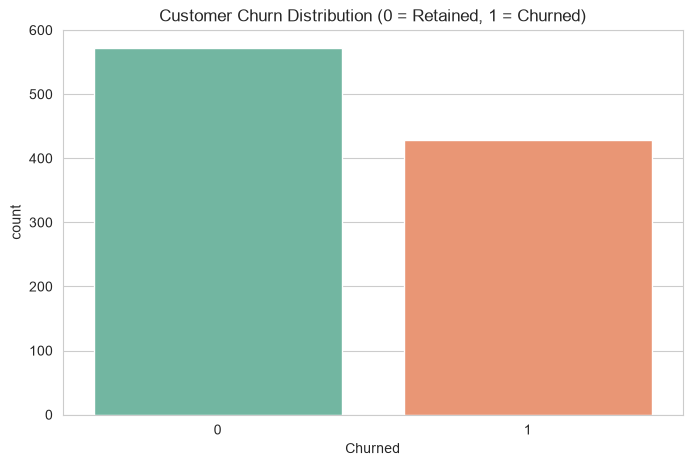

In [71]:
# Churn distribution
churn_counts = df["Churned"].value_counts()
print(churn_counts)
print(f"Churn rate: {churn_counts[1] / df.shape[0] * 100:.1f}%")

plt.figure()
sns.countplot(x="Churned", hue="Churned", data=df, palette="Set2", legend=False)
plt.title("Customer Churn Distribution (0 = Retained, 1 = Churned)")
plt.show()


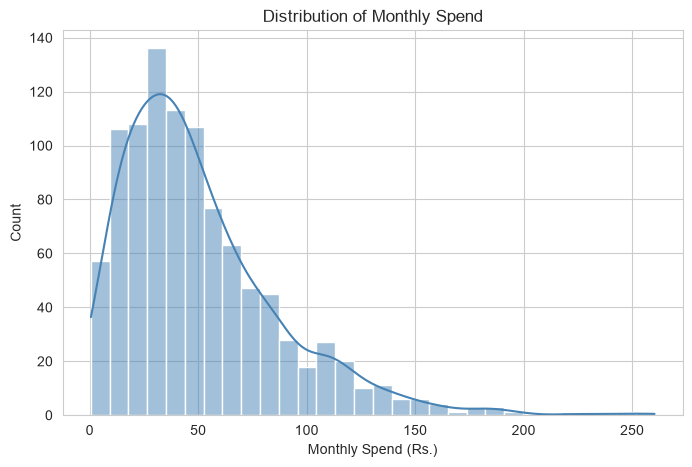

In [72]:
# Spending distribution
plt.figure()
sns.histplot(df["Monthly_Spend"], bins=30, kde=True, color="steelblue")
plt.title("Distribution of Monthly Spend")
plt.xlabel("Monthly Spend (Rs.)")
plt.show()


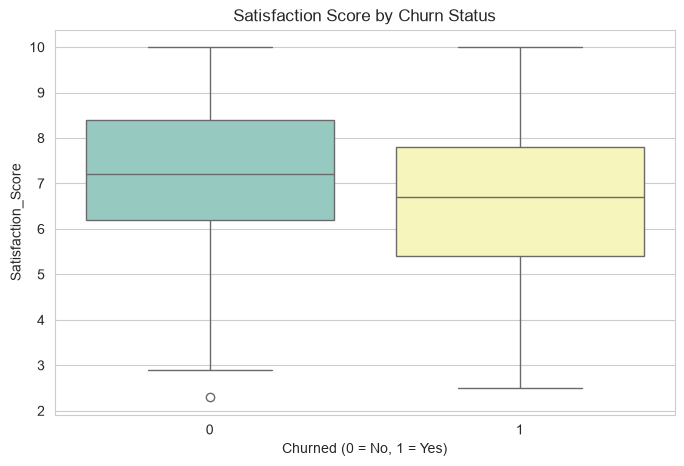

In [73]:
# Satisfaction score vs churn
plt.figure()
sns.boxplot(x="Churned", y="Satisfaction_Score", hue="Churned", data=df, palette="Set3", legend=False)
plt.title("Satisfaction Score by Churn Status")
plt.xlabel("Churned (0 = No, 1 = Yes)")
plt.show()


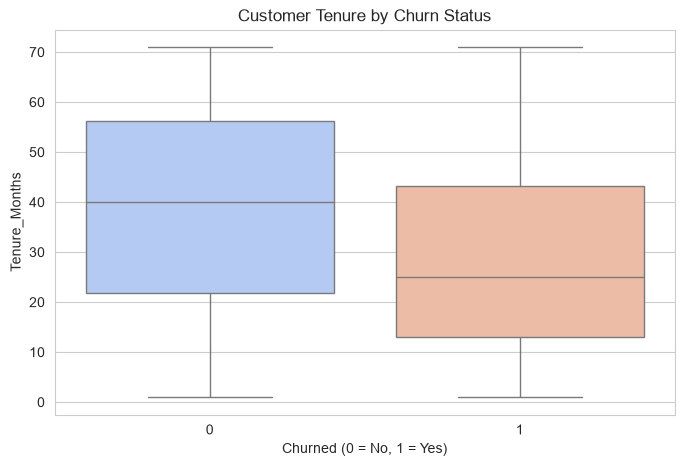

In [74]:
# Tenure vs churn
plt.figure()
sns.boxplot(x="Churned", y="Tenure_Months", hue="Churned", data=df, palette="coolwarm", legend=False)
plt.title("Customer Tenure by Churn Status")
plt.xlabel("Churned (0 = No, 1 = Yes)")
plt.show()


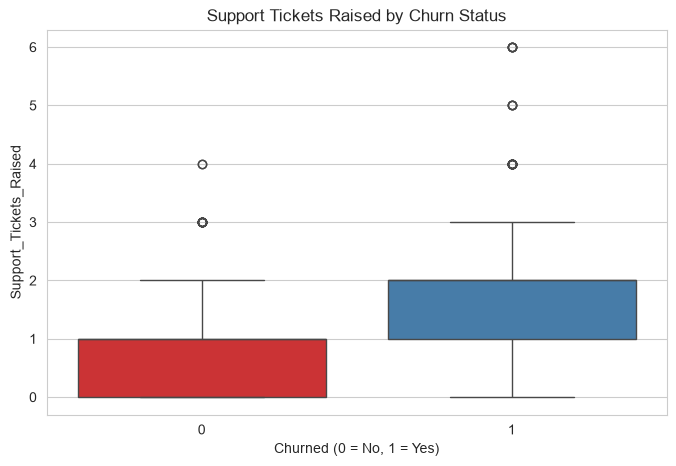

In [75]:
# Support tickets vs churn
plt.figure()
sns.boxplot(x="Churned", y="Support_Tickets_Raised", hue="Churned", data=df, palette="Set1", legend=False)
plt.title("Support Tickets Raised by Churn Status")
plt.xlabel("Churned (0 = No, 1 = Yes)")
plt.show()


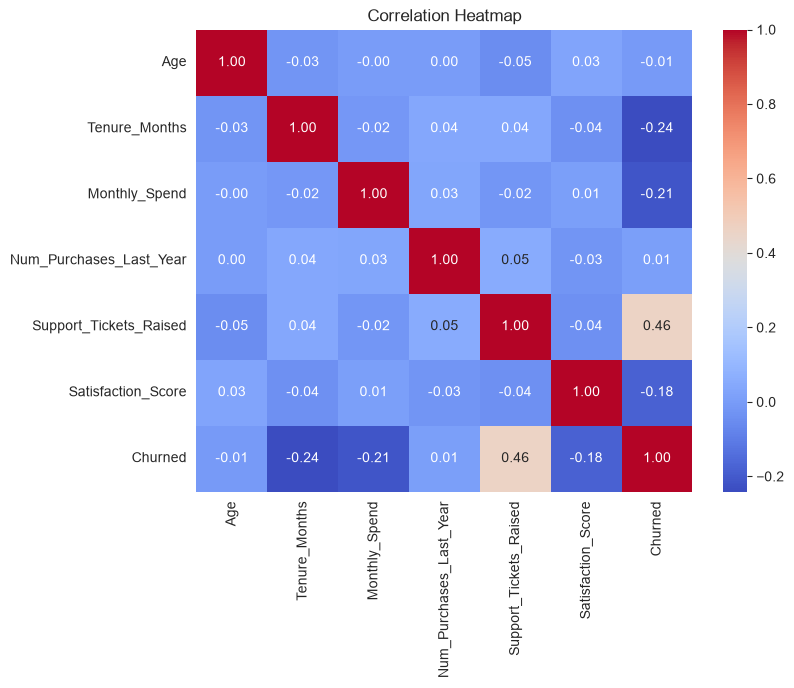

In [76]:
# Correlation heatmap of numeric features
plt.figure(figsize=(8, 6))
numeric_cols = ["Age", "Tenure_Months", "Monthly_Spend", "Num_Purchases_Last_Year",
                "Support_Tickets_Raised", "Satisfaction_Score", "Churned"]
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


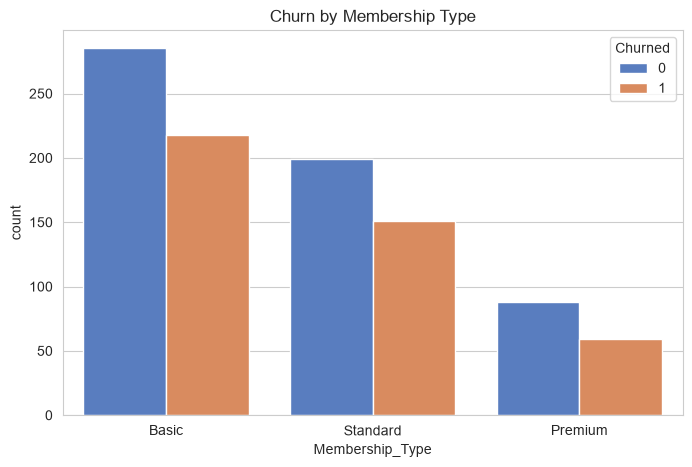

In [77]:
# Membership type breakdown
plt.figure()
sns.countplot(x="Membership_Type", hue="Churned", data=df, palette="muted")
plt.title("Churn by Membership Type")
plt.show()


## 5. Customer Segmentation

We segment customers using K-Means clustering based on behavior: spend, purchase frequency,
tenure, and satisfaction. This groups customers into meaningful business segments such as
"high-value loyal customers" vs "at-risk low-engagement customers".


In [78]:
segment_features = df[["Tenure_Months", "Monthly_Spend", "Num_Purchases_Last_Year", "Satisfaction_Score"]]

scaler = StandardScaler()
segment_scaled = scaler.fit_transform(segment_features)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df["Segment"] = kmeans.fit_predict(segment_scaled)

df.groupby("Segment")[["Tenure_Months", "Monthly_Spend", "Num_Purchases_Last_Year", "Satisfaction_Score", "Churned"]].mean().round(2)


,Tenure_Months,Monthly_Spend,Num_Purchases_Last_Year,Satisfaction_Score,Churned
Segment,,,,,
0,29.56,36.03,10.52,5.98,0.56
1,57.53,42.21,7.19,7.23,0.29
2,19.13,40.41,6.23,7.66,0.50
3,32.27,120.27,8.57,6.77,0.27


         Tenure_Months  Monthly_Spend  Satisfaction_Score   Churned
Segment                                                            
0            29.555133      36.028194            5.978707  0.562738
1            57.531469      42.211888            7.232867  0.293706
2            19.126582      40.414763            7.656646  0.503165
3            32.266667     120.274815            6.771111  0.274074


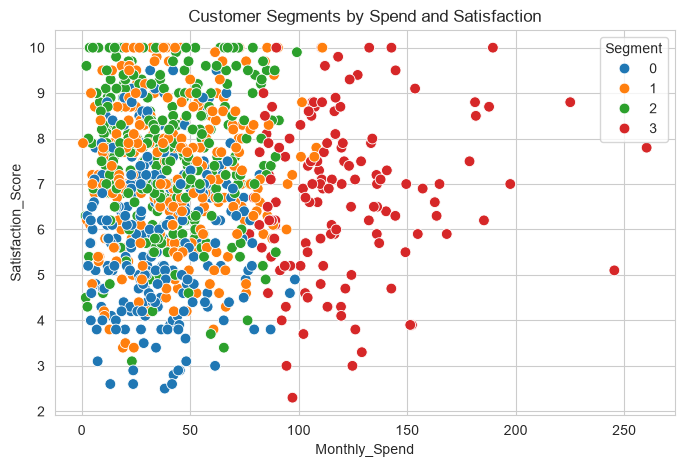

In [79]:
# Label segments based on their characteristics (interpret the clusters)
segment_summary = df.groupby("Segment")[["Tenure_Months", "Monthly_Spend", "Satisfaction_Score", "Churned"]].mean()
print(segment_summary)

# Visualize segments
plt.figure()
sns.scatterplot(x="Monthly_Spend", y="Satisfaction_Score", hue="Segment", data=df, palette="tab10", s=60)
plt.title("Customer Segments by Spend and Satisfaction")
plt.show()


## 6. Behavior Pattern Identification

Key patterns observed so far (from EDA + segmentation):
- Customers with **lower satisfaction scores** and **more support tickets** are noticeably more likely to churn.
- **Longer-tenured customers** are more loyal — churn is concentrated among newer customers.
- Spend alone is not a strong churn signal by itself, but combined with satisfaction it matters more.
- Segmentation reveals at least one "at-risk" cluster: shorter tenure, lower satisfaction, fewer purchases.


## 7. Churn Prediction (Basic Predictive Model)

We build a simple Logistic Regression model — interpretable and a strong baseline for churn problems.


In [80]:
# Encode categorical variables
model_df = df.copy()
model_df = pd.C(model_df, columns=["Gender", "City_Tier", "Membership_Type"], drop_first=True)

feature_cols = [c for c in model_df.columns if c not in
                 ["Customer_ID", "Churned", "Segment"]]

X = model_df[feature_cols]
y = model_df["Churned"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

scaler2 = StandardScaler()
X_train_scaled = scaler2.fit_transform(X_train)
X_test_scaled = scaler2.transform(X_test)

print("Train size:", X_train.shape, " Test size:", X_test.shape)


Train size: (750, 11)  Test size: (250, 11)


In [81]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("Accuracy: ", round(accuracy_score(y_test, y_pred), 3))
print("Precision:", round(precision_score(y_test, y_pred), 3))
print("Recall:   ", round(recall_score(y_test, y_pred), 3))
print()
print(classification_report(y_test, y_pred))


Accuracy:  0.82
Precision: 0.878
Recall:    0.673

              precision    recall  f1-score   support

           0       0.79      0.93      0.86       143
           1       0.88      0.67      0.76       107

    accuracy                           0.82       250
   macro avg       0.83      0.80      0.81       250
weighted avg       0.83      0.82      0.82       250



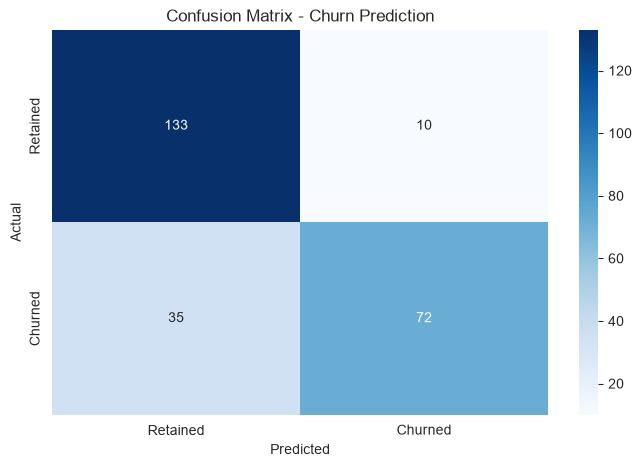

In [82]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Retained", "Churned"], yticklabels=["Retained", "Churned"])
plt.title("Confusion Matrix - Churn Prediction")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()


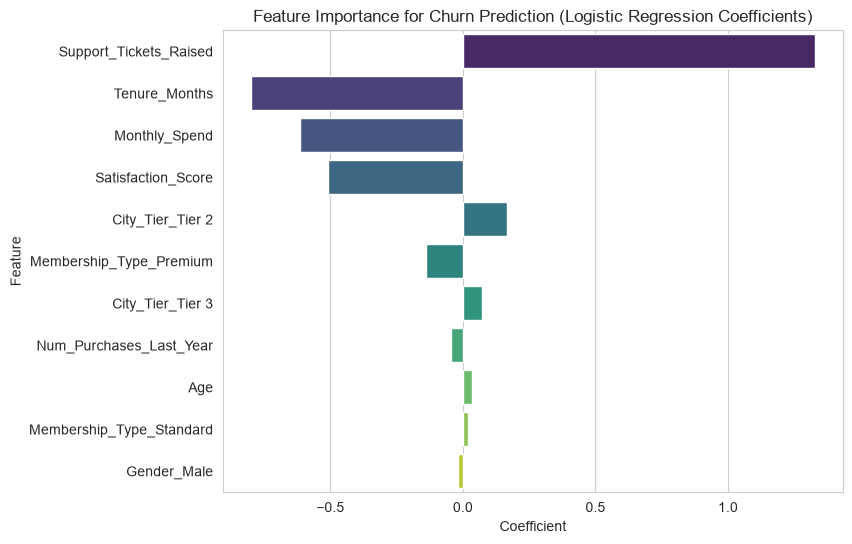

,Feature,Coefficient
4,Support_Tickets_Raised,1.327487
1,Tenure_Months,-0.799124
2,Monthly_Spend,-0.613817
5,Satisfaction_Score,-0.507622
7,City_Tier_Tier 2,0.165592
9,Membership_Type_Premium,-0.140016
8,City_Tier_Tier 3,0.071318
3,Num_Purchases_Last_Year,-0.044643
0,Age,0.035093
10,Membership_Type_Standard,0.019818


In [83]:
# Which features matter most for churn? (coefficient magnitude)
coef_df = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": model.coef_[0]
}).sort_values(by="Coefficient", key=abs, ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x="Coefficient", y="Feature", hue="Feature", data=coef_df, palette="viridis", legend=False)
plt.title("Feature Importance for Churn Prediction (Logistic Regression Coefficients)")
plt.show()

coef_df


In [84]:
# Identify high-risk customers (predicted probability of churn)
model_df["Churn_Probability"] = model.predict_proba(scaler2.transform(X))[:, 1]
high_risk = model_df[model_df["Churn_Probability"] > 0.7].sort_values("Churn_Probability", ascending=False)
print(f"Number of high-risk customers (>70% churn probability): {len(high_risk)}")
high_risk[["Customer_ID", "Tenure_Months", "Satisfaction_Score", "Support_Tickets_Raised", "Churn_Probability"]].head(10)


Number of high-risk customers (>70% churn probability): 226


,Customer_ID,Tenure_Months,Satisfaction_Score,Support_Tickets_Raised,Churn_Probability
135,CUST1135,3,4.1,6,0.999631
658,CUST1658,31,4.6,6,0.999298
564,CUST1564,17,7.3,5,0.993491
162,CUST1162,41,10.0,6,0.990566
318,CUST1318,70,6.8,6,0.990239
583,CUST1583,36,4.7,4,0.986948
816,CUST1816,21,4.5,4,0.981931
109,CUST1109,15,4.3,3,0.980915
849,CUST1849,5,9.1,4,0.979492
219,CUST1219,18,6.4,4,0.978675


## 8. Business-Focused Insight Report

### Key Findings
1. **Overall churn rate** is meaningful — roughly 4 in 10 customers in this dataset have churned, which is a serious retention concern.
2. **Satisfaction score is the strongest churn predictor.** Customers with low satisfaction (driven largely by support issues) churn far more often.
3. **Support tickets matter a lot.** Customers raising more support tickets are significantly more likely to leave — this points to unresolved service issues as a major churn driver.
4. **Tenure protects against churn.** Newer customers (low tenure) are the most vulnerable segment — the first few months are critical for retention efforts.
5. **Segmentation reveals an actionable "at-risk" cluster**: short tenure + low satisfaction + low purchase frequency. This group should be prioritized for proactive outreach.

### Recommendations
- **Launch a "First 90 Days" retention program** targeting new customers with proactive check-ins, since tenure is a strong protective factor.
- **Improve support resolution speed and quality** — since support tickets correlate so strongly with churn, reducing ticket volume or improving first-contact resolution could directly reduce churn.
- **Use the churn probability score** generated by this model to create a prioritized outreach list for the retention team — start with the highest-risk customers identified above.
- **Re-engagement campaigns for the "at-risk" segment** identified through clustering — targeted discounts, personalized offers, or satisfaction surveys.

### Model Limitations
- This model is a baseline (Logistic Regression) — useful for interpretability, but a more powerful model (Random Forest, XGBoost) could likely improve recall on the churn class.
- The dataset here is synthetic/sample data for demonstration; a production model would need real historical data, more features (e.g. complaint text, channel of contact), and regular retraining.
